# 4. Bandes de phonons 


#### Imports et récupération de la structure

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pymatgen.ext.matproj import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.diffraction.xrd import XRDCalculator

from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.phonon.plotter import PhononBSPlotter

from scipy.optimize import curve_fit
from scipy.constants import hbar, k as k_B

API_KEY = "vKJsFu0jdhLy7CJj5Mwar6S68kxgMc3n"
MP_ID = "mp-1008556"  

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(MP_ID)
    phonon_bs = mpr.get_phonon_bandstructure_by_material_id(MP_ID)


## 4.1 Structure de bandes de phonons du matériau attribué ainsi que sa zone de Brillouin

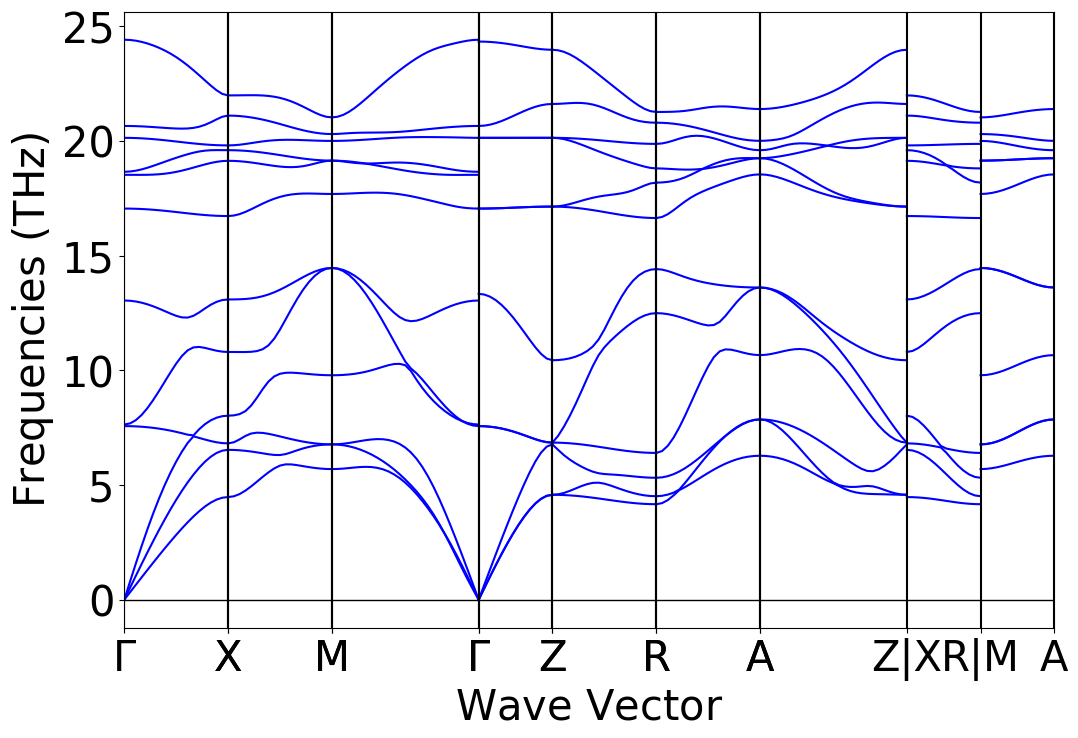

In [2]:
plotter = PhononBSPlotter(phonon_bs)
fig = plotter.get_plot()  

plt.savefig(f"{MP_ID}_phonon_bandstructure.png", dpi=300, bbox_inches="tight")
plt.show()

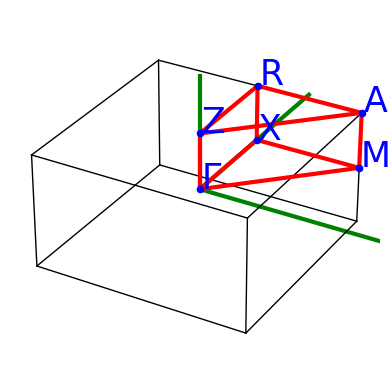

In [3]:
# Zone de Brillouin
ph_plot = PhononBSPlotter(phonon_bs)
ph_plot.plot_brillouin()

## 4.2 Vitesse du son pour trois branches acoustiques différentes dans trois directions différentes de la zone de Brillouin

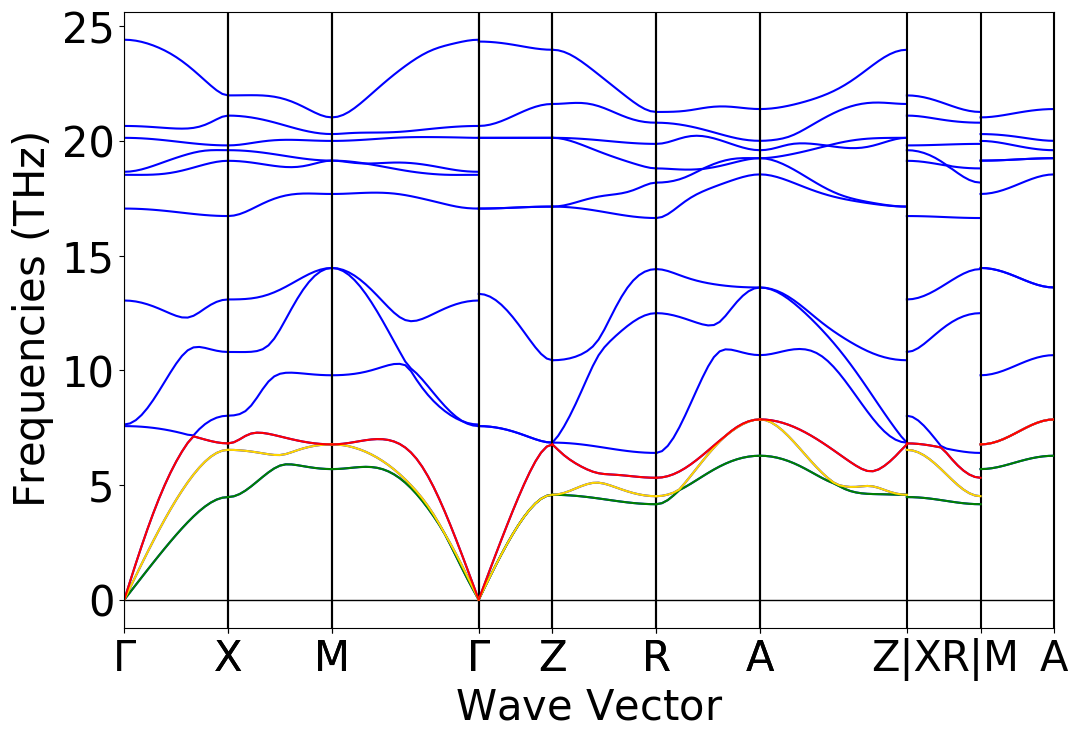

In [4]:
data = PhononBSPlotter(phonon_bs).bs_plot_data()
distances = data['distances']
frequences = data['frequency']
directions = data['ticks']['label']

ph_plot.get_plot()

for i in range(len(distances)):
    plt.plot(distances[i], frequences[i][0], 'green')
    plt.plot(distances[i], frequences[i][1], 'gold')
    plt.plot(distances[i], frequences[i][2], 'red')


Notre cristal contient 4 atomes par maille primitive, cela signifie qu'il existe 3N = 12 modes de vibration. 
Parmi ces modes :
- 3 sont des modes acoustiques  
- 9 sont des modes optiques  

Dans notre cas, nous nous intéressons uniquement aux 3 branches acoustiques :
- deux modes transverses (TA)  
- un mode longitudinal (LA) 

Lorsque le vecteur d'onde $\vec{q} \rightarrow 0$, c'est à dire proche du point $\Gamma$, nous pouvons faire l'hypothèse d'une relation de dispersion des phonons acoustiques linéaire. La vitesse du son est ainsi donnée par : $$v_{\text{son}} = \frac{d\omega}{dq}$$ où $$\omega = 2\pi f$$

Cette approximation est valable car les branches acoustiques du diagramme de dispersion des phonons présentent un comportement linéaire au voisinage du point $\Gamma$, qui correspond à l’origine de la première zone de Brillouin.

Pour déterminer la vitesse du son dans une direction donnée, on calcule la pente de la tangente aux branches acoustiques au point $\Gamma$. La valeur absolue de cette pente correspond à la vitesse de propagation de l’onde acoustique dans la direction considérée.

Il ne faut pas oublier d'appliquer une correction par un facteur $10^2$ car nous travaillons avec des fréquences exprimées en tétrahertz ($10^{12}$ Hz) et que les distances sont en Angström ($10^{-10}$ m).

Les vitesses du son sont calculées le long des directions suivantes : $\Gamma \rightarrow X$, $\Gamma \rightarrow Z$, $\Gamma \rightarrow M$.

In [5]:
conversion = 1e12 / 1e10
# Vitesse v = 2 * pi * df / dq

# signification des indices de frequences : [chemin/e/2points][branche][val_freq_pour_ce_point]
# signification des indices de distances : [chemin/e/2points][coord_q_axeH]

# 1ere branche acoustique Gamma - X
d_freq1 = (frequences[0][0][1] - frequences[0][0][0])
d_dist1 = distances[0][1] - distances[0][0]

v_1 = np.abs(2 * np.pi * (d_freq1 / d_dist1) * conversion)
print(f"La vitesse du son pour la branche Γ-X de la zone de Brillouin : {v_1:.2f} [m/s]")

# 2eme branche acoustique Gamma - Z
d_freq2 = frequences[3][1][1] - frequences[3][1][0]
d_dist2 = distances[3][1] - distances[3][0]

v_2 =  np.abs(2 * np.pi * (d_freq2 / d_dist2) * conversion)
print(f"La vitesse du son pour la branche Γ-Z de la zone de Brillouin : {v_2:.2f} [m/s]")

# 3eme branhce acoustiqye Gamma - M
d_freq3 = frequences[2][2][-1] - frequences[2][2][-2]
d_dist3 = distances[2][-1] - distances[2][-2]

v_3 =  np.abs(2 * np.pi * (d_freq3 / d_dist3) * conversion)
print(f"La vitesse du son pour la branche Γ-M de la zone de Brillouin : {v_3:.2f} [m/s]")

La vitesse du son pour la branche Γ-X de la zone de Brillouin : 3673.83 [m/s]
La vitesse du son pour la branche Γ-Z de la zone de Brillouin : 5840.04 [m/s]
La vitesse du son pour la branche Γ-M de la zone de Brillouin : 7694.99 [m/s]


Les vitesses calculées, s'étalant de $3673 \text{ m/s}$ à environ $7700 \text{ m/s}$, témoignent de la forte rigidité des liaisons atomiques au sein du cristal AlGaN2. Ces valeurs élevées sont caractéristiques des semi-conducteurs à large bande interdite.

Sur le graphique de dispersion des phonons ci-dessous, ces vitesses correspondent physiquement à la pente des branches acoustiquesà l'origine (point $\Gamma$).

Nous remarquons que la vitesse varie selon la direction de propagation. Cette dépendance selon l'orientation montre que le réseau cristallin n'est pas isotrope.
La vitesse la plus élevée est observée dans la direction $\Gamma \rightarrow M$ ($\sim 7695 \text{ m/s}$), tandis que la direction $\Gamma \rightarrow X$ présente la vitesse la plus faible ($\sim 3674 \text{ m/s}$). 
Cette différence reflète l'anisotropie élastique du cristal : les atomes sont liés plus rigidement ou sont plus denses dans une direction que dans l'autre, dans notre cas dans la direction $\Gamma \rightarrow M$, ce qui permet à l'onde de vibration de se propager plus vite.

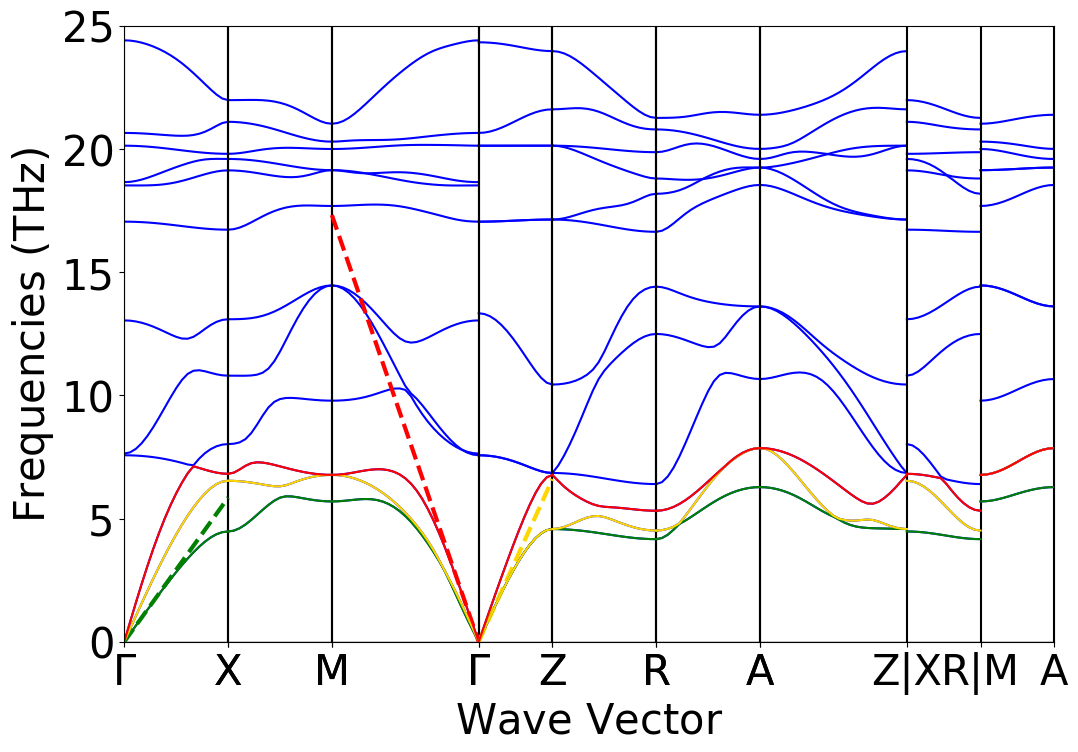

In [6]:
ph_plot.get_plot()
plt.plot()

# direction 1
x1 = np.array([distances[0][0], distances[0][1]])
y1 = np.array([frequences[0][0][0], frequences[0][0][1]])
c1 = np.polyfit(x1, y1, 1)
a1 = np.linspace(distances[0][0], distances[0][-1], 100)
p1 = c1[0]*a1 + c1[1]

# direction 2
x2 = np.array([distances[3][0], distances[3][1]])
y2 = np.array([frequences[3][1][0], frequences[3][1][1]])
c2 = np.polyfit(x2, y2, 1)
a2 = np.linspace(distances[3][0], distances[3][-1], 100)
p2 = c2[0]*a2 + c2[1]

# direction 3
x3 = np.array([distances[2][-2], distances[2][-1]])
y3 = np.array([frequences[2][2][-2], frequences[2][2][-1]])
c3 = np.polyfit(x3, y3, 1)
a3 = np.linspace(distances[2][0], distances[2][-1], 100)
p3 = c3[0]*a3 + c3[1]


plt.plot(a1, p1, color ="green", ls='--', lw = 3)
plt.plot(a2, p2, color ="gold", ls='--', lw = 3)
plt.plot(a3, p3, color='red', ls='--', lw = 3)
plt.ylim(0,25)
for i in range(len(distances)):
    plt.plot(distances[i], frequences[i][0], 'green')
    plt.plot(distances[i], frequences[i][1], 'gold')
    plt.plot(distances[i], frequences[i][2], 'red')

La branche rouge sur le graphique correspond au mode longitudinal (LA), tandis que les branches verte et jaune correspondent aux modes transverses (TA).